<a href="https://www.kaggle.com/code/lalit7881/central-bank-rates-1945-2026?scriptVersionId=304426529" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kanchana1990/central-bank-rates-intelligence-19452026/global_central_bank_rates_1945_2026.csv


## Loading dataset

In [2]:
file_path = "/kaggle/input/datasets/kanchana1990/central-bank-rates-intelligence-19452026/global_central_bank_rates_1945_2026.csv"

df = pd.read_csv(file_path)

## Basic Exploration

In [3]:
df.head()          # first 5 rows
df.tail()          # last 5 rows
df.shape           # (rows, columns)
df.columns         # column names
df.info()          # data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24454 entries, 0 to 24453
Data columns (total 43 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   country_code                      24454 non-null  object 
 1   date                              24454 non-null  object 
 2   policy_rate_pct                   24454 non-null  float64
 3   rate_description                  24454 non-null  object 
 4   rate_notes                        24454 non-null  object 
 5   source_institution                24454 non-null  object 
 6   year                              24454 non-null  int64  
 7   month                             24454 non-null  int64  
 8   time_period                       24454 non-null  object 
 9   country_name                      24454 non-null  object 
 10  central_bank                      24454 non-null  object 
 11  region                            24454 non-null  object 
 12  cont

## Summary Statistics

In [4]:
df.describe()

,policy_rate_pct,year,month,population,dataset_version,rate_change_bps,rate_jan2022_base,cumulative_change_since_2022_bps,rate_3m_avg,rate_12m_avg,rate_12m_max,rate_12m_min,is_all_time_high,is_all_time_low,gfc_period,covid_period,hike_cycle_2022_23,fed_rate,spread_vs_fed_bps,row_completeness_pct
count,24454.000000,24454.000000,24454.000000,2.412800e+04,24454.0,2.440500e+04,16002.000000,1.600200e+04,24454.000000,24356.000000,24356.000000,24356.000000,24454.000000,24454.000000,24454.000000,24454.000000,24454.000000,22975.000000,2.297500e+04,24454.0
mean,39.827068,1993.766051,6.496933,1.308478e+08,1.0,-5.823684e+00,3.247219,5.342542e+03,39.888138,40.233195,212.560216,8.352345,0.170034,0.252678,0.039257,0.035373,0.036763,4.018083,3.815941e+03,100.0
std,2460.594166,22.101651,3.456628,3.178766e+08,0.0,2.863195e+05,6.408020,3.041285e+05,1807.103477,1082.950373,7947.465381,56.743729,0.375670,0.434557,0.194211,0.184723,0.188183,3.413941,2.538498e+05,0.0
min,0.000000,1945.000000,1.000000,3.918100e+05,1.0,-3.547345e+07,0.000000,-3.989000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.125000,-1.900000e+03,100.0
25%,3.000000,1977.000000,3.000000,1.013480e+07,1.0,0.000000e+00,0.250000,1.000000e+02,3.000000,3.083000,3.500000,2.750000,0.000000,0.000000,0.000000,0.000000,0.000000,1.125000,0.000000e+00,100.0
50%,5.000000,1998.000000,6.500000,3.682833e+07,1.0,0.000000e+00,1.500000,3.000000e+02,5.000000,5.021000,5.500000,4.500000,0.000000,0.000000,0.000000,0.000000,0.000000,3.875000,1.500000e+02,100.0
75%,8.250000,2012.000000,10.000000,6.928144e+07,1.0,0.000000e+00,4.000000,6.000000e+02,8.250000,8.320250,9.412500,7.250000,0.000000,1.000000,0.000000,0.000000,0.000000,5.500000,4.250000e+02,100.0
max,355085.640000,2026.000000,12.000000,1.417492e+09,1.0,2.579474e+07,40.000000,3.550764e+07,185236.047000,50773.835000,355085.640000,2699.410000,1.000000,1.000000,1.000000,1.000000,1.000000,22.000000,3.550774e+07,100.0


## Check Missing Values

In [5]:
df.isnull().sum()

country_code                           0
date                                   0
policy_rate_pct                        0
rate_description                       0
rate_notes                             0
source_institution                     0
year                                   0
month                                  0
time_period                            0
country_name                           0
central_bank                           0
region                                 0
continent                              0
subregion                              0
population                           326
currency                               0
capital                                0
data_source                            0
dataset_version                        0
retrieved_date                         0
build_timestamp                        0
month_name                             0
quarter                                0
decade                                 0
rate_change_bps 

## Data Cleaning

### Remove duplicates

In [6]:
df.drop_duplicates(inplace=True)

## Fill missing values

In [7]:
# numeric columns
df.fillna(df.mean(numeric_only=True), inplace=True)

# categorical columns
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

## Correlation

In [8]:
df.corr(numeric_only=True)

,policy_rate_pct,year,month,population,dataset_version,rate_change_bps,rate_jan2022_base,cumulative_change_since_2022_bps,rate_3m_avg,rate_12m_avg,rate_12m_max,rate_12m_min,is_all_time_high,is_all_time_low,gfc_period,covid_period,hike_cycle_2022_23,fed_rate,spread_vs_fed_bps,row_completeness_pct
policy_rate_pct,1.000000,-0.002018,-0.007249,0.003332,NaN,0.581223,0.016393,0.999857,0.727461,0.347349,0.317061,0.117721,0.017490,-0.008402,-0.002809,-0.002870,-0.002580,0.014121,0.999992,NaN
year,-0.002018,1.000000,-0.008233,-0.004047,NaN,-0.000079,0.078909,-0.007988,-0.002652,-0.004245,-0.004023,-0.004110,-0.506770,0.050757,0.134760,0.231628,0.254055,-0.364944,-0.003438,NaN
month,-0.007249,-0.008233,1.000000,-0.000350,NaN,0.002552,-0.000864,-0.007166,-0.011683,-0.000109,-0.000058,-0.003985,-0.002370,-0.011967,0.000179,0.000010,0.001839,0.006908,-0.007299,NaN
population,0.003332,-0.004047,-0.000350,1.000000,NaN,0.000007,0.039095,0.001238,0.004525,0.007491,0.006527,0.009376,0.146532,-0.015063,-0.001788,0.004446,0.001473,-0.006414,0.003351,NaN
dataset_version,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rate_change_bps,0.581223,-0.000079,0.002552,0.000007,NaN,1.000000,0.000003,0.581304,-0.017941,-0.051171,-0.046473,0.007432,0.014074,-0.000099,-0.000005,0.000002,0.000022,0.000019,0.581237,NaN
rate_jan2022_base,0.016393,0.078909,-0.000864,0.039095,NaN,0.000003,1.000000,0.014289,0.022317,0.037286,0.030153,0.076375,-0.025654,-0.070966,0.014892,0.015657,0.015369,-0.057534,0.016400,NaN
cumulative_change_since_2022_bps,0.999857,-0.007988,-0.007166,0.001238,NaN,0.581304,0.014289,1.000000,0.727177,0.346799,0.316822,0.112918,0.019155,-0.008738,-0.003784,-0.004209,-0.003781,0.017184,0.999854,NaN
rate_3m_avg,0.727461,-0.002652,-0.011683,0.004525,NaN,-0.017941,0.022317,0.727177,1.000000,0.550094,0.506245,0.143386,0.008771,-0.011309,-0.003817,-0.003909,-0.003550,0.019229,0.727434,NaN
rate_12m_avg,0.347349,-0.004245,-0.000109,0.007491,NaN,-0.051171,0.037286,0.346799,0.550094,1.000000,0.983950,0.152313,-0.004722,-0.018309,-0.006365,-0.006530,-0.006226,0.030683,0.347284,NaN


## Columns

In [9]:
df.columns

Index(['country_code', 'date', 'policy_rate_pct', 'rate_description',
       'rate_notes', 'source_institution', 'year', 'month', 'time_period',
       'country_name', 'central_bank', 'region', 'continent', 'subregion',
       'population', 'currency', 'capital', 'data_source', 'dataset_version',
       'retrieved_date', 'build_timestamp', 'month_name', 'quarter', 'decade',
       'rate_change_bps', 'rate_change_direction', 'rate_jan2022_base',
       'cumulative_change_since_2022_bps', 'rate_cycle', 'rate_regime',
       'rate_3m_avg', 'rate_12m_avg', 'rate_12m_max', 'rate_12m_min',
       'is_all_time_high', 'is_all_time_low', 'era', 'gfc_period',
       'covid_period', 'hike_cycle_2022_23', 'fed_rate', 'spread_vs_fed_bps',
       'row_completeness_pct'],
      dtype='object')

In [10]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Drop missing key values
df = df.dropna(subset=['policy_rate_pct'])

## EDA

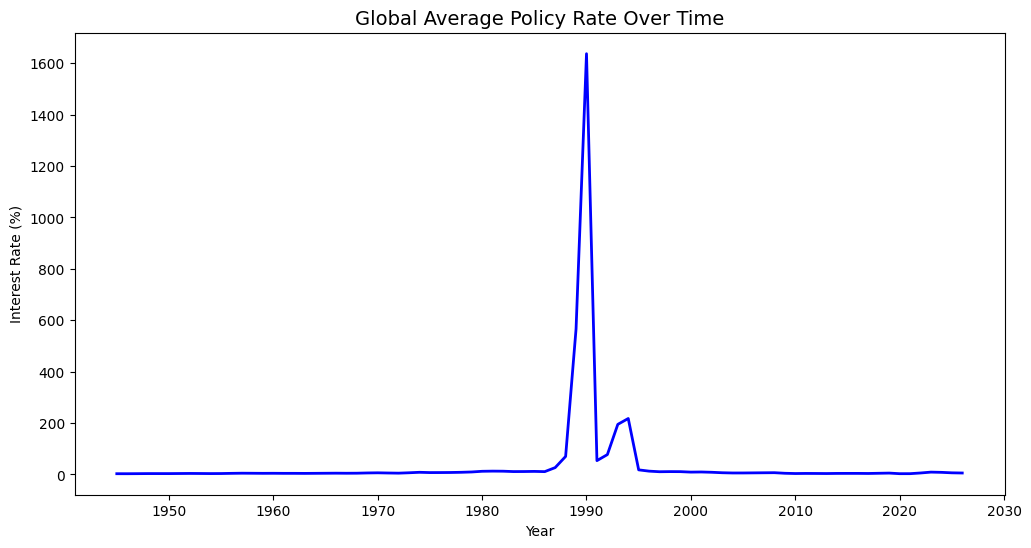

In [11]:
plt.figure(figsize=(12,6))

df.groupby('year')['policy_rate_pct'].mean().plot(
    color='blue', linewidth=2
)

plt.title("Global Average Policy Rate Over Time", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Interest Rate (%)")
plt.show()

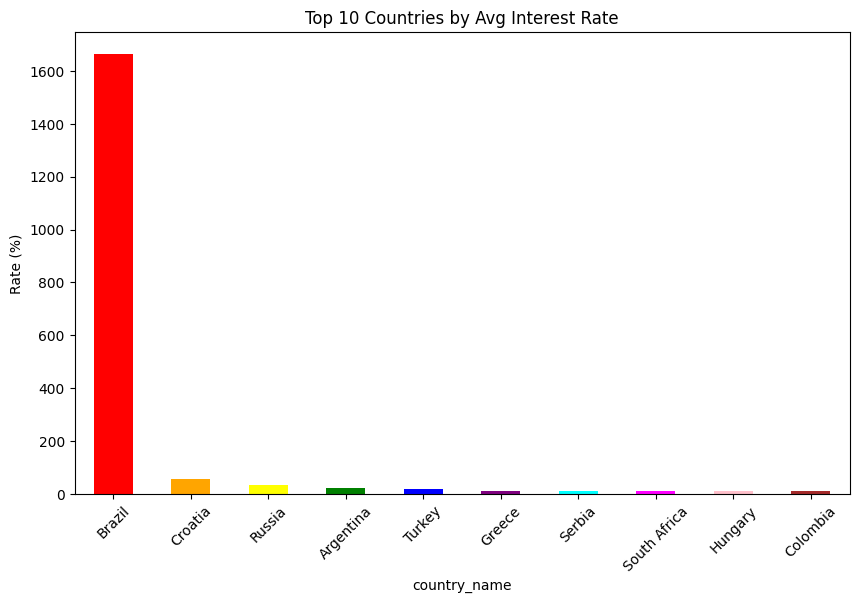

In [12]:
top_countries = df.groupby('country_name')['policy_rate_pct'] \
                  .mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

top_countries.plot(
    kind='bar',
    color=['red','orange','yellow','green','blue','purple','cyan','magenta','pink','brown']
)

plt.title("Top 10 Countries by Avg Interest Rate")
plt.ylabel("Rate (%)")
plt.xticks(rotation=45)
plt.show()

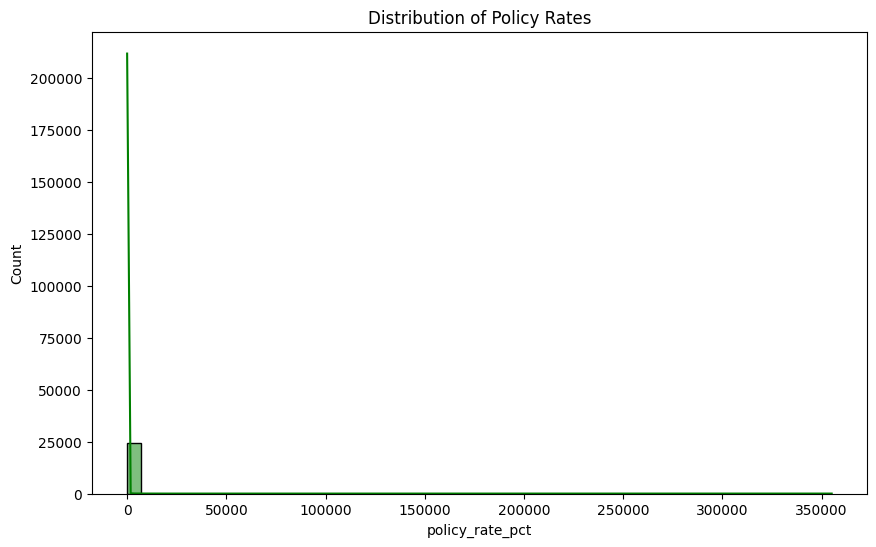

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['policy_rate_pct'],
    bins=50,
    kde=True,
    color='green'
)

plt.title("Distribution of Policy Rates")
plt.show()

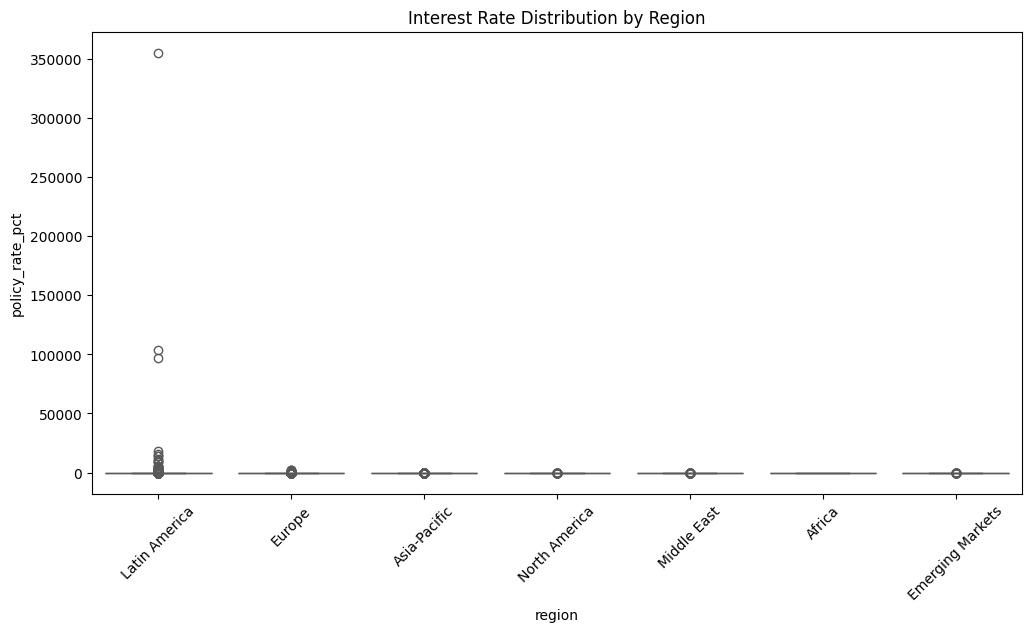

In [14]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='region',
    y='policy_rate_pct',
    data=df,
    palette='Set2'
)

plt.xticks(rotation=45)
plt.title("Interest Rate Distribution by Region")
plt.show()

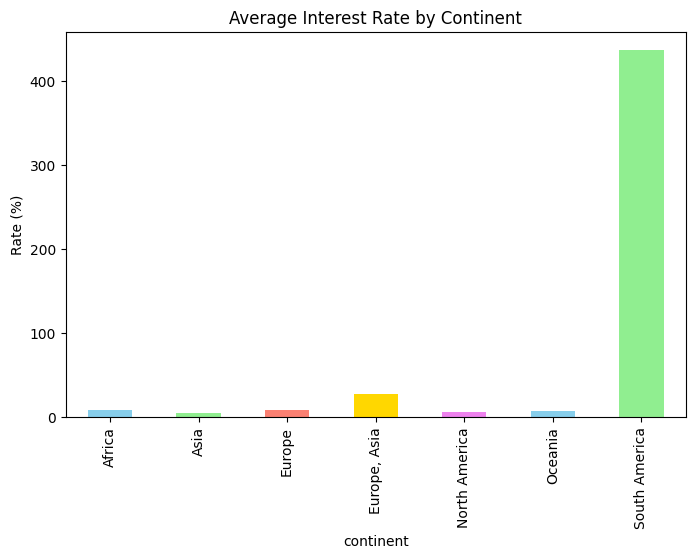

In [15]:
continent_avg = df.groupby('continent')['policy_rate_pct'].mean()

plt.figure(figsize=(8,5))

continent_avg.plot(
    kind='bar',
    color=['skyblue','lightgreen','salmon','gold','violet']
)

plt.title("Average Interest Rate by Continent")
plt.ylabel("Rate (%)")
plt.show()

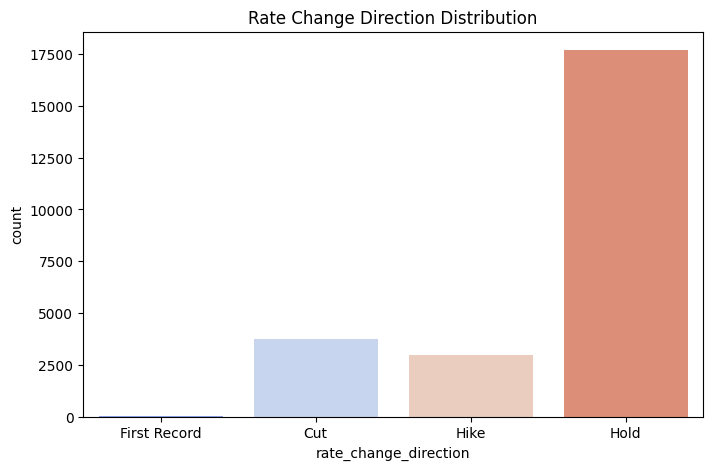

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='rate_change_direction',
    data=df,
    palette='coolwarm'
)

plt.title("Rate Change Direction Distribution")
plt.show()

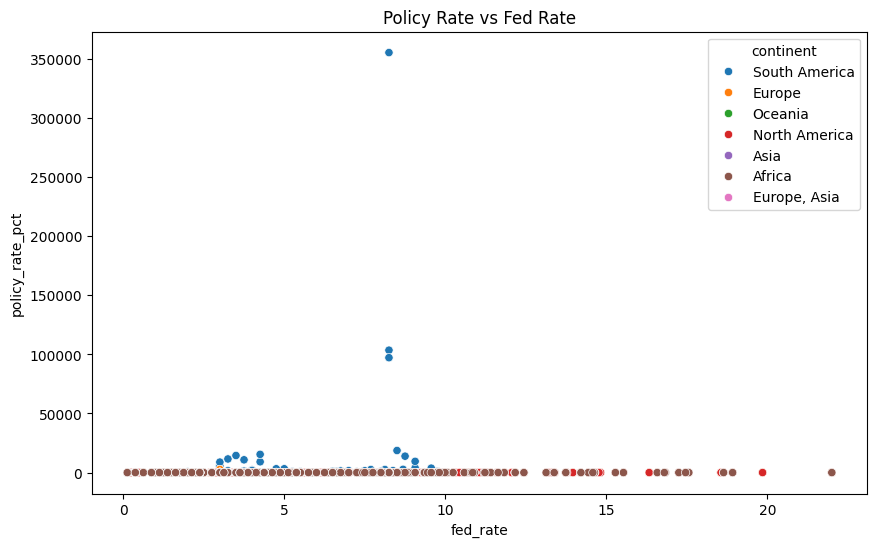

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='fed_rate',
    y='policy_rate_pct',
    data=df,
    hue='continent',
    palette='tab10'
)

plt.title("Policy Rate vs Fed Rate")
plt.show()

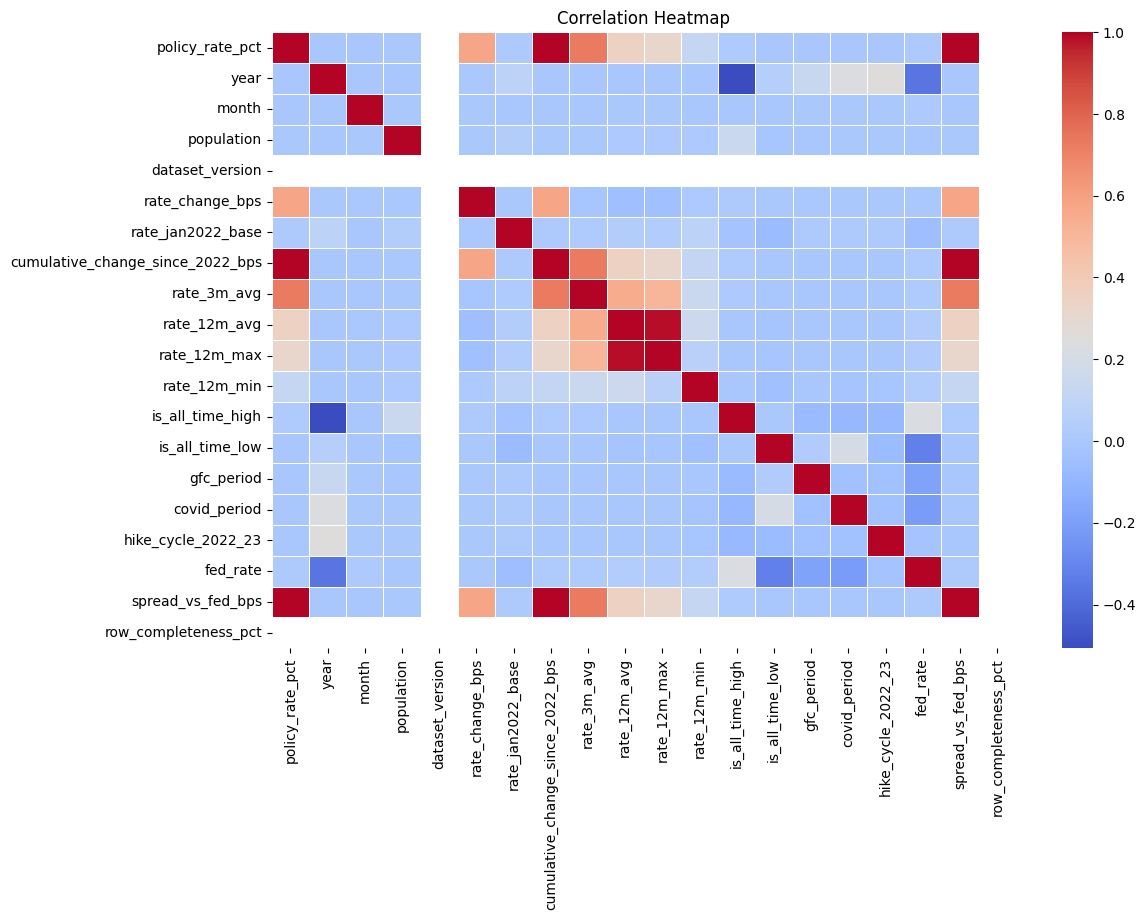

In [18]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

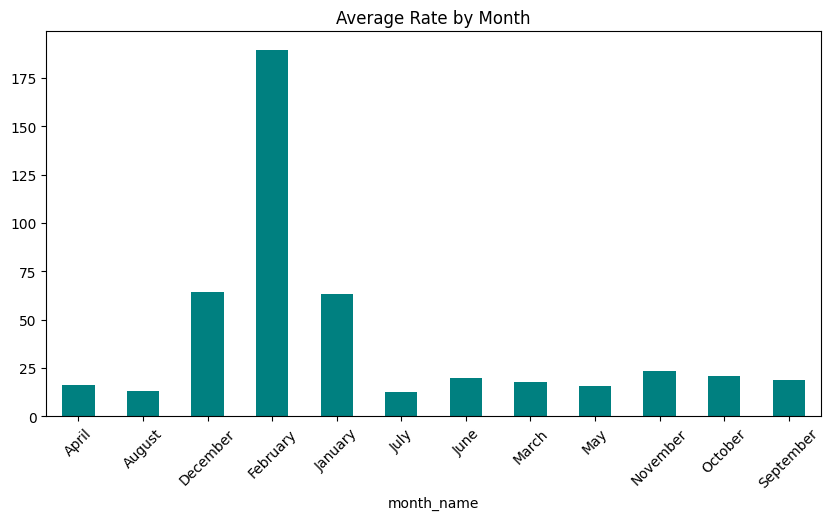

In [19]:
monthly = df.groupby('month_name')['policy_rate_pct'].mean()

plt.figure(figsize=(10,5))

monthly.plot(
    kind='bar',
    color='teal'
)

plt.title("Average Rate by Month")
plt.xticks(rotation=45)
plt.show()

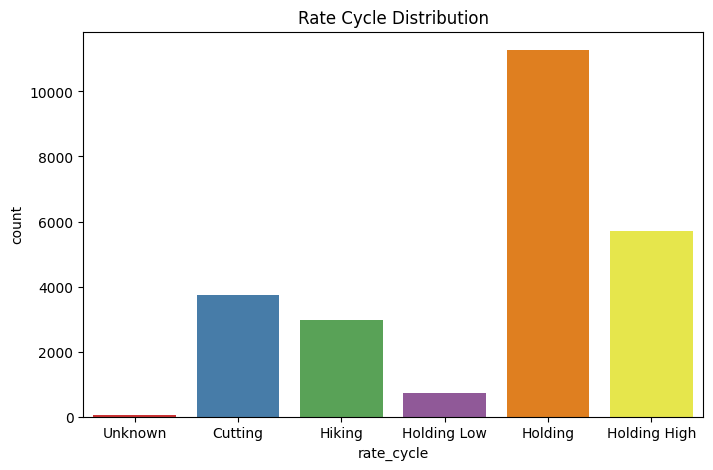

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='rate_cycle',
    data=df,
    palette='Set1'
)

plt.title("Rate Cycle Distribution")
plt.show()

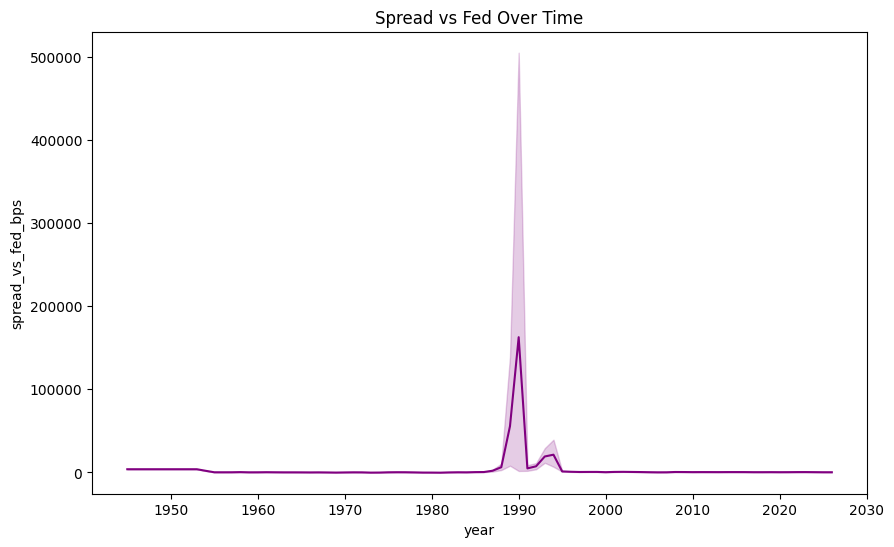

In [21]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x='year',
    y='spread_vs_fed_bps',
    data=df,
    color='purple'
)

plt.title("Spread vs Fed Over Time")
plt.show()

## Feature engineering

In [22]:
import plotly.express as px

In [23]:
# 🌍 Line Chart (Global Trend)
fig = px.line(
    df.groupby('year')['policy_rate_pct'].mean().reset_index(),
    x='year',
    y='policy_rate_pct',
    title="Global Policy Rate Trend",
    color_discrete_sequence=['blue']
)
fig.show()

# 🌎 Country Comparison
fig = px.line(
    df[df['country_name'].isin(['India','United States','United Kingdom'])],
    x='date',
    y='policy_rate_pct',
    color='country_name',
    title="Country-wise Interest Rate Trend"
)
fig.show()

# 📊 Scatter Plot
fig = px.scatter(
    df,
    x='fed_rate',
    y='policy_rate_pct',
    color='continent',
    size='population',
    title="Policy Rate vs Fed Rate"
)
fig.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.



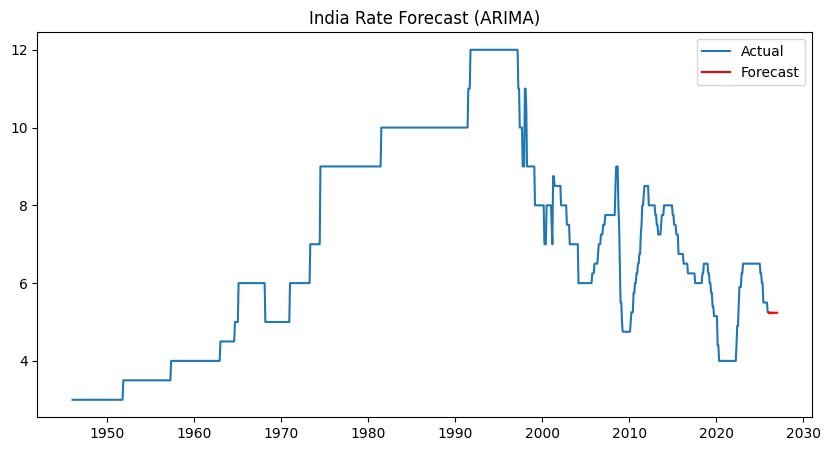

In [24]:
from statsmodels.tsa.arima.model import ARIMA
# Example: India
india = df[df['country_name'] == 'India']
india = india.sort_values('date')

ts = india.set_index('date')['policy_rate_pct']

# Train model
model = ARIMA(ts, order=(2,1,2))
model_fit = model.fit()

# Forecast next 12 steps
forecast = model_fit.forecast(steps=12)

# Plot
plt.figure(figsize=(10,5))
plt.plot(ts, label='Actual')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.title("India Rate Forecast (ARIMA)")
plt.show()

## ML Model (Predict Rate Change Direction)

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Copy data
df_ml = df.copy()

# Drop useless columns
df_ml.drop(['date','country_name','central_bank','currency','capital'], axis=1, inplace=True)

# Encode categorical
le = LabelEncoder()
for col in df_ml.select_dtypes(include='object'):
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

# Target
X = df_ml.drop('rate_change_direction', axis=1)
y = df_ml['rate_change_direction']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       758
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00       603
           3       1.00      1.00      1.00      3525

    accuracy                           1.00      4891
   macro avg       1.00      1.00      1.00      4891
weighted avg       1.00      1.00      1.00      4891



## Feature Importance

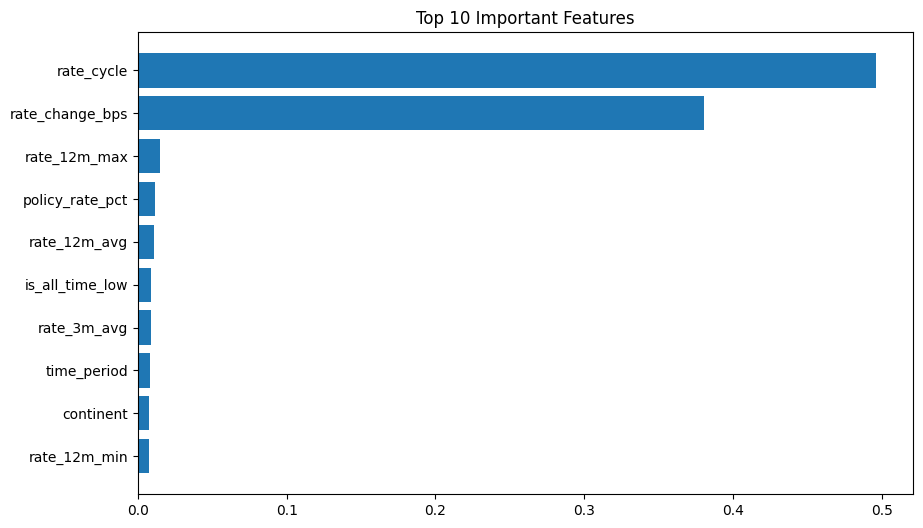

In [26]:
importance = model.feature_importances_
features = X.columns

imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(imp_df['Feature'][:10], imp_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

## Thank you...pls upvote!!!!!!